In [1]:
import pandas as pd
import numpy as np

In [2]:
# load dataset
df = pd.read_csv("Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
# Initial audit
print("Shape:", df.shape)
print("Data types:\n", df.dtypes)
print("Missing values:\n", df.isnull().sum())

Shape: (13320, 9)
Data types:
 area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object
Missing values:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [5]:
# cleaning
df = df.dropna(subset=['location', 'size'])

In [6]:
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())


In [7]:
df.isnull().sum()

area_type          0
availability       0
location           0
size               0
society         5499
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64

In [8]:
df['society'].nunique()

2676

In [9]:
df['society'].value_counts()

society
GrrvaGr    80
PrarePa    76
Prtates    59
Sryalan    59
GMown E    56
           ..
SuMTBPr     1
i1odsne     1
NantsGa     1
G harth     1
CoDast      1
Name: count, Length: 2676, dtype: int64

In [10]:
df = df.drop(columns=['society'])


In [11]:
# feature extraction
df['bhk'] = df['size'].apply(lambda x: int(x.split()[0]))

In [12]:
df[['size','bhk']].head(10)

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2
5,2 BHK,2
6,4 BHK,4
7,4 BHK,4
8,3 BHK,3
9,6 Bedroom,6


In [13]:
# Drop the original size column
df = df.drop(['size'], axis='columns')

In [14]:
print("Unique BHK values:", df['bhk'].unique())
print("Max BHK:", df['bhk'].max())


Unique BHK values: [ 2  4  3  6  1  8  7  5 11  9 27 10 19 16 43 14 12 13 18]
Max BHK: 43


In [15]:
print("Min BHK:", df['bhk'].min())
print("Max BHK:", df['bhk'].max())
print("Average BHK:", df['bhk'].mean())


Min BHK: 1
Max BHK: 43
Average BHK: 2.803728482297226


In [16]:
df = df[df['bhk'] <10]

In [17]:
print("Unique BHK values after cleaning:", df['bhk'].unique())
print("Max BHK after cleaning:", df['bhk'].max())


Unique BHK values after cleaning: [2 4 3 6 1 8 7 5 9]
Max BHK after cleaning: 9


In [18]:
def convert_sqft(x):
    try:
        if '-' in x:  # handles ranges like "1000-1200"
            nums = x.split('-')
            return (float(nums[0]) + float(nums[1])) / 2
        else:         
            return float(x)
    except:           
        return None


In [19]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft)


In [20]:
df = df.dropna(subset=['total_sqft']) # Drop rows where conversion failed

In [21]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2


In [22]:
print(df[['bhk','total_sqft']].head(10))
print("Data type:", df['total_sqft'].dtype)
print("Min sqft:", df['total_sqft'].min())
print("Max sqft:", df['total_sqft'].max())

   bhk  total_sqft
0    2      1056.0
1    4      2600.0
2    3      1440.0
3    3      1521.0
4    2      1200.0
5    2      1170.0
6    4      2732.0
7    4      3300.0
8    3      1310.0
9    6      1020.0
Data type: float64
Min sqft: 1.0
Max sqft: 52272.0


In [23]:
# Remove unrealistic sqft values
df = df[(df['total_sqft'] >= 300) & (df['total_sqft'] <= 10000)]

In [24]:
print("Min sqft after cleaning:", df['total_sqft'].min())
print("Max sqft after cleaning:", df['total_sqft'].max())

Min sqft after cleaning: 300.0
Max sqft after cleaning: 10000.0


In [25]:
# Feature Engineering & Outlier Removal
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']


In [26]:
print("Min price_per_sqft:", df['price_per_sqft'].min())
print("Max price_per_sqft:", df['price_per_sqft'].max())
print("Average price_per_sqft:", df['price_per_sqft'].mean())


Min price_per_sqft: 500.0
Max price_per_sqft: 176470.58823529413
Average price_per_sqft: 6677.071889879923


In [27]:
df = df[(df['price_per_sqft'] >= 1000) & (df['price_per_sqft'] <= 20000)]

In [28]:
print("Min price_per_sqft after cleaning:", df['price_per_sqft'].min())
print("Max price_per_sqft after cleaning:", df['price_per_sqft'].max())
print("Average price_per_sqft after cleaning:", df['price_per_sqft'].mean())

Min price_per_sqft after cleaning: 1166.6666666666667
Max price_per_sqft after cleaning: 20000.0
Average price_per_sqft after cleaning: 6322.818682355597


In [29]:
df = df[(df['total_sqft']/df['bhk']) >= 300]


In [30]:
df['location'] = df['location'].apply(lambda x: x.strip())
location_stats = df['location'].value_counts()
less_than_10 = location_stats[location_stats <= 10]
df['location'] = df['location'].apply(lambda x: 'other' if x in less_than_10 else x)


In [31]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df['price_per_sqft']),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df['price_per_sqft'] < stats['mean']].index.values)
    return df.drop(exclude_indices, axis='index')



In [32]:
# Apply the function
df = remove_bhk_outliers(df)

print("Dataset shape after removing BHK outliers:", df.shape)

Dataset shape after removing BHK outliers: (8585, 9)


In [33]:
print(df['price_per_sqft'].head())
print(df['price_per_sqft'].dtype)
print(df['price_per_sqft'].describe())


0    3699.810606
2    4305.555556
3    6245.890861
4    4250.000000
6    7467.057101
Name: price_per_sqft, dtype: float64
float64
count     8585.000000
mean      6690.289974
std       3136.107300
min       1166.666667
25%       4629.629630
50%       5952.380952
75%       7542.147294
max      20000.000000
Name: price_per_sqft, dtype: float64


In [34]:
df['price_per_sqft'] = pd.to_numeric(df['price_per_sqft'], errors='coerce')


In [35]:
df['price_per_sqft'] = df['price_per_sqft'].astype(float)


In [36]:
print(df['price_per_sqft'].head())
print(df['price_per_sqft'].dtype)
print(df['price_per_sqft'].describe())


0    3699.810606
2    4305.555556
3    6245.890861
4    4250.000000
6    7467.057101
Name: price_per_sqft, dtype: float64
float64
count     8585.000000
mean      6690.289974
std       3136.107300
min       1166.666667
25%       4629.629630
50%       5952.380952
75%       7542.147294
max      20000.000000
Name: price_per_sqft, dtype: float64


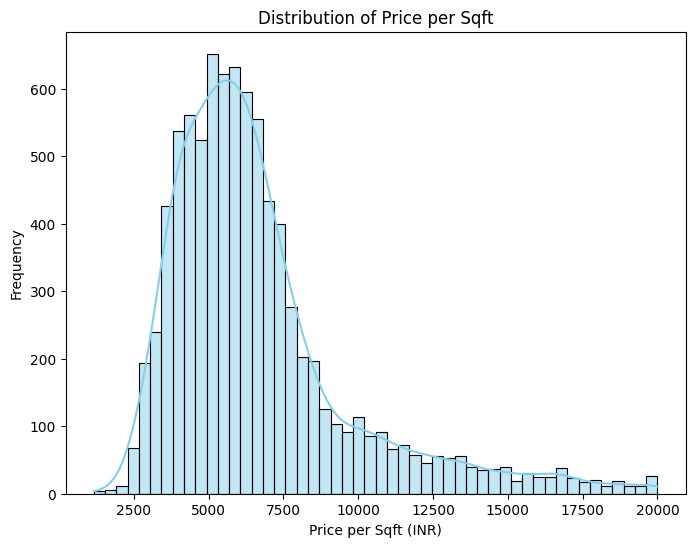

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df['price_per_sqft'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Price per Sqft")
plt.xlabel("Price per Sqft (INR)")
plt.ylabel("Frequency")
plt.show()


- The distribution is right-skewed, showing fewer but very expensive properties.
- Most properties fall between ₹4,000–₹8,000 per sqft.  

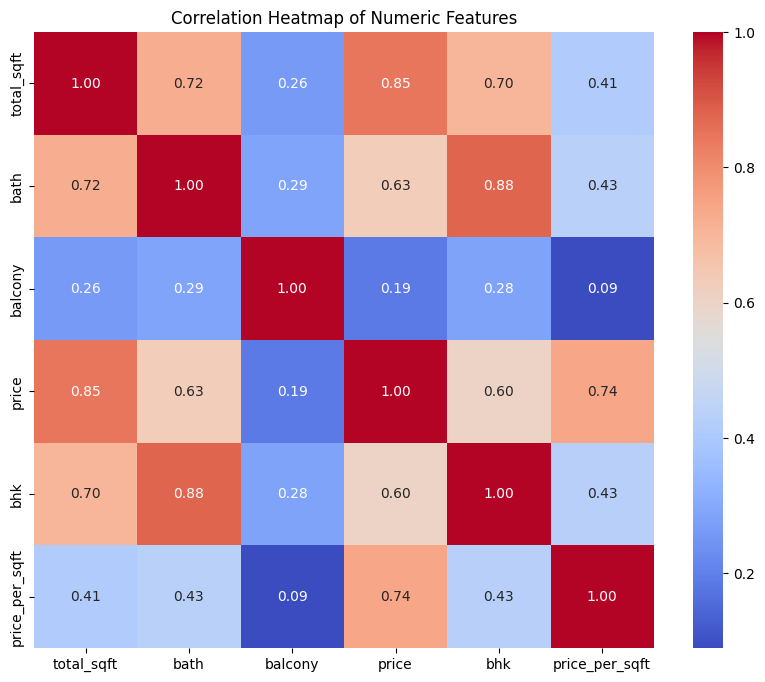

In [38]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=['float64','int64']).corr() 
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



- Price is strongly correlated with total_sqft (≈0.85). 

C:\Users\Aifa\AppData\Local\Temp\ipykernel_26236\4247009150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bhk', y='price', data=df, palette="Set2")


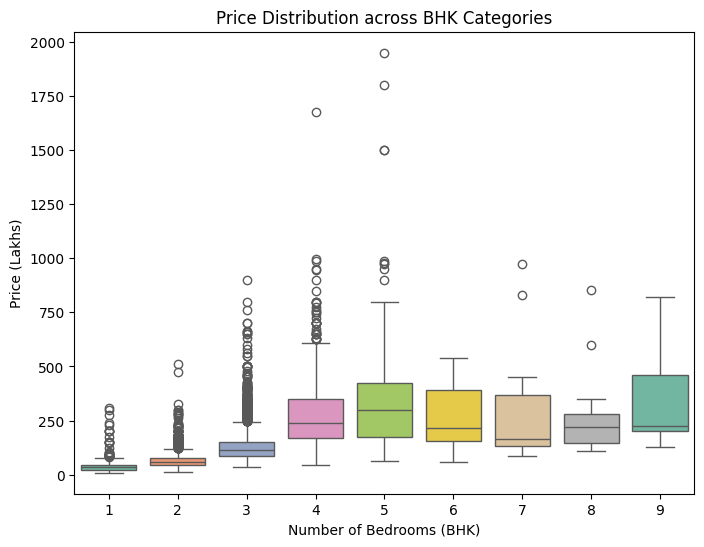

In [39]:
plt.figure(figsize=(8,6))
sns.boxplot(x='bhk', y='price', data=df, palette="Set2")
plt.title("Price Distribution across BHK Categories")
plt.xlabel("Number of Bedrooms (BHK)")
plt.ylabel("Price (Lakhs)")
plt.show()


- Median price increases with BHK count.  
- Higher BHKs show wider variation due to luxury villas vs regular apartments.

In [40]:
# encoding,Scaling, preprocessing
X = df.drop(['price', 'availability'], axis='columns')
y = df['price']


In [ ]:
# area_type is categorical - apply one encoding
X = pd.get_dummies(X, columns=['area_type'], drop_first=True)


In [42]:
# label encoding on the top 20 most frequent
# locations (map all others to "Other").
from sklearn.preprocessing import LabelEncoder

location_stats = df['location'].value_counts()
top_20_locations = location_stats[:20].index

X['location'] = X['location'].apply(lambda x: x if x in top_20_locations else 'Other')

le = LabelEncoder()
X['location'] = le.fit_transform(X['location'])

In [43]:
X.head()

,location,total_sqft,bath,balcony,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,4,1056.0,2.0,1.0,2,3699.810606,False,False,True
2,17,1440.0,2.0,3.0,3,4305.555556,False,False,False
3,11,1521.0,3.0,1.0,3,6245.890861,False,False,True
4,11,1200.0,2.0,1.0,2,4250.000000,False,False,True
6,11,2732.0,4.0,2.0,4,7467.057101,False,False,True


In [44]:
# Apply Min-Max scaling to total_sqft and bath.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X[['total_sqft','bath']] = scaler.fit_transform(X[['total_sqft','bath']])


- area_type: One-hot encoding because it has categories with no order.  
- location: Label encoding after keeping top 20 frequent ones, others grouped as "Other".  
- total_sqft and bath: Min-Max scaling so values are normalized between 0–1 and large ranges don’t dominate.


**Supervised Learning**

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
y_pred = lr.predict(X_test)

In [49]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 36.25358033120784
MAE: 18.096794089034738
R2: 0.9015585733132203


In [50]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [51]:
y_pred_ridge = ridge.predict(X_test)

In [52]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [53]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [54]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [55]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [rmse, rmse_ridge, rmse_lasso],
    'MAE': [mae, mae_ridge, mae_lasso],
    'R2': [r2, r2_ridge, r2_lasso]
})

print(results)

               Model       RMSE        MAE        R2
0  Linear Regression  36.253580  18.096794  0.901559
1   Ridge Regression  36.061695  17.908232  0.902598
2   Lasso Regression  36.012452  17.919877  0.902864


Linear regression predicts prices, but Ridge and Lasso make the model less likely to overfit by keeping the numbers smaller and more balanced.

In [62]:
#q7:Create binary target
# high_value = 1 if price >= 100 lakhs, else 0
df['high_value'] = (df['price'] >= 100).astype(int)

# One-hot encode area_type
X = pd.get_dummies(X, columns=['area_type'], drop_first=True)

# Simplify and encode location
from sklearn.preprocessing import LabelEncoder
location_stats = df['location'].value_counts()
top_20_locations = location_stats[:20].index
X['location'] = X['location'].apply(lambda x: x if x in top_20_locations else 'Other')


In [63]:
le = LabelEncoder()
X['location'] = le.fit_transform(X['location'])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [66]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

d:\ICT__DSA\exit_exam\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [68]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)


In [70]:
# Logistic Regression metrics
y_pred_log = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

# Naive Bayes metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)


In [71]:
# Results table
results_q7 = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [acc_log, acc_nb],
    'Precision': [prec_log, prec_nb],
    'Recall': [rec_log, rec_nb],
    'F1-score': [f1_log, f1_nb]
})
print(results_q7)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.975539   0.972085  0.959481  0.965742
1          Naive Bayes  0.896913   0.867893  0.841167  0.854321


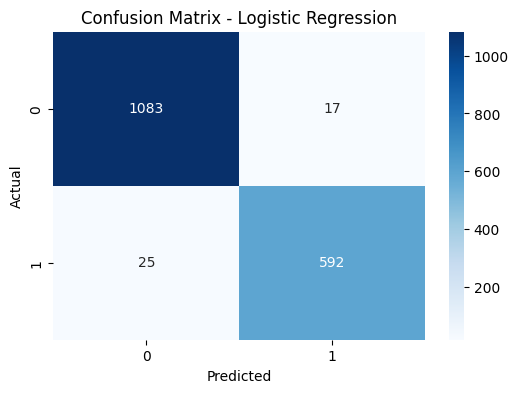

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Pick the better model based on F1-score
if f1_log >= f1_nb:
    cm = confusion_matrix(y_test, y_pred_log)
    model_name = "Logistic Regression"
else:
    cm = confusion_matrix(y_test, y_pred_nb)
    model_name = "Naive Bayes"

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Logistic Regression was better than Naive Bayes because it predicted expensive houses more correctly

In [73]:
#q8: Random Forest with GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [74]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [75]:
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [76]:
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [78]:
best_rf = grid_search.best_estimator_  # best model from gridsearchCV

In [79]:
# Predict on test set
y_pred_rf = best_rf.predict(X_test)

In [81]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.0792779184374587
Random Forest MAE: 0.012478159580663948
Random Forest R2: 0.9726997126491823


In [82]:
results_q8 = pd.DataFrame({
    'Model': ['Linear Regression','Ridge Regression','Lasso Regression','Random Forest'],
    'RMSE': [rmse, rmse_ridge, rmse_lasso, rmse_rf],
    'MAE': [mae, mae_ridge, mae_lasso, mae_rf],
    'R2': [r2, r2_ridge, r2_lasso, r2_rf]
})
print(results_q8)

               Model       RMSE        MAE        R2
0  Linear Regression  36.253580  18.096794  0.901559
1   Ridge Regression  36.061695  17.908232  0.902598
2   Lasso Regression  36.012452  17.919877  0.902864
3      Random Forest   0.079278   0.012478  0.972700


Random Forest gave the best results because it uses many trees together, which makes predictions stronger and less likely to overfit.

**Unsupervised Learning & Dimensionality Reduction**

In [83]:
#Q9: K-Means Clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [84]:
# Features for clustering
X_cluster = df[['total_sqft','bath','price_per_sqft']]

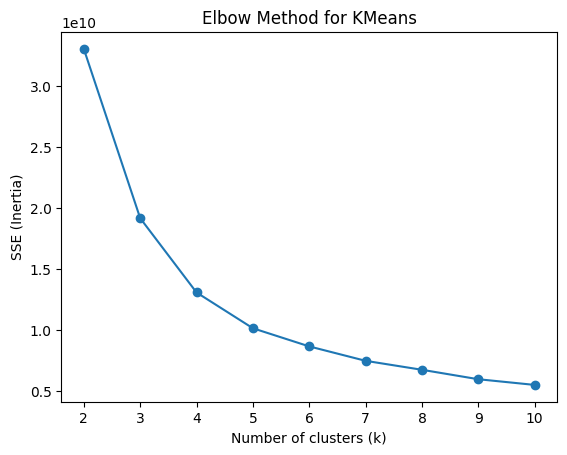

In [85]:
# Elbow method
sse = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    sse.append(kmeans.inertia_)

plt.plot(range(2,11), sse, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for KMeans")
plt.show()

In [88]:
# Choose optimal k ( k=4 )
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

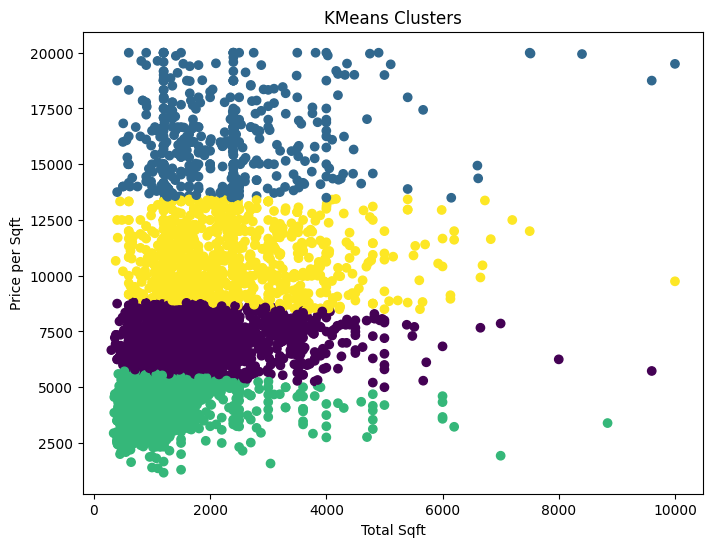

In [90]:
# Visualise clusters (2D scatter using sqft vs price_per_sqft)
plt.figure(figsize=(8,6))
plt.scatter(df['total_sqft'], df['price_per_sqft'], c=df['cluster'], cmap='viridis')
plt.xlabel("Total Sqft")
plt.ylabel("Price per Sqft")
plt.title("KMeans Clusters")
plt.show()

In [91]:
#q10:PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [93]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=9)
pca.fit(X_scaled)

,n_components,9
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


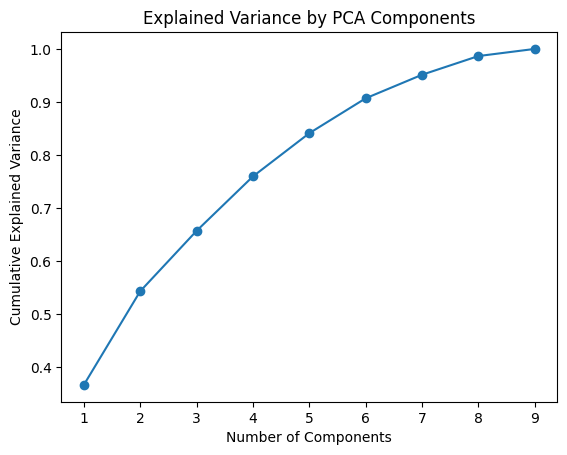

In [94]:
plt.plot(range(1,10), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()


In [95]:
# Reduce to top 5 components
pca_5 = PCA(n_components=5)
X_pca = pca_5.fit_transform(X_scaled)

# Train-test split
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)


In [96]:
log_reg_pca = LogisticRegression(max_iter=1000)
log_reg_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = log_reg_pca.predict(X_test_pca)


In [97]:
print("Accuracy:", accuracy_score(y_test_pca, y_pred_pca))
print("Precision:", precision_score(y_test_pca, y_pred_pca))
print("Recall:", recall_score(y_test_pca, y_pred_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_pca))


Accuracy: 0.88351776354106
Precision: 0.8304278922345484
Recall: 0.8492706645056726
F1-score: 0.8397435897435898


In [98]:
results_q10 = pd.DataFrame({
    'Model': ['Logistic Regression (Full Features)', 'Logistic Regression (PCA, 5 comps)'],
    'Accuracy': [0.975539, 0.883518],
    'Precision': [0.972085, 0.830428],
    'Recall': [0.959481, 0.849271],
    'F1-score': [0.965742, 0.839744]
})
print(results_q10)


                                 Model  Accuracy  Precision    Recall  \
0  Logistic Regression (Full Features)  0.975539   0.972085  0.959481   
1   Logistic Regression (PCA, 5 comps)  0.883518   0.830428  0.849271   

   F1-score  
0  0.965742  
1  0.839744  


Using PCA with 5 components made the model faster and simpler, but accuracy dropped compared to the full feature set.

**Deployment — Streamlit Web App**

In [103]:
print(df.columns)


Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk', 'price_per_sqft', 'high_value', 'cluster'],
      dtype='object')


In [106]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ['location']   # only location is categorical
numeric_features = ['bhk', 'total_sqft', 'bath', 'balcony']  # numeric inputs

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])


In [ ]:
from sklearn.pipeline import Pipeline
import pickle

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_rf)   #  Random Forest
])

pipeline.fit(X_train, y_train)

# Save pipeline
pickle.dump(pipeline, open("best_model.pkl", "wb"))



In [109]:
df.to_csv("cleaned_data.csv", index=False)


We’ll deploy the Random Forest model since it gave the best accuracy, and use it in the Streamlit app to predict house prices.